In [1]:
import random
import networkx as nx
import numpy as np
from community import best_partition
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix

In [4]:

#vincent's blondel
def my_network(PPP):
    GG = nx.Graph()  # or DiGraph, MultiGraph, MultiDiGraph, etc
    for u,v,w in PPP: GG.add_weighted_edges_from([(u, v, w)])
    return GG 

def Louvain(G):
    c = best_partition(G)
    unique_c = np.unique(list(c.values()))
    return c,unique_c

#def Louvain(G):
#    c = community_louvain.best_partition(G)
#    unique_c = np.unique(list(c.values()))
#    return c,unique_c

def reducePP(P,c):
    unique_c = np.unique(list(c.values()))
    Z = np.zeros((len(c),len(unique_c)))  # consolidation matrix 
    for i in range(len(c)): Z[i,c[i]] = 1  
    P = Z.T@P@Z
    for i,p in enumerate(P): P[i,:] = p/sum(p)
    return P 

def P2G(P):
    PP = coo_matrix(P)       # convert to (i,j,k) triplet 
    rr,cc,dd = PP.tocoo().row, PP.tocoo().col, PP.tocoo().data 
    PPP = [(i,j,k) for (i,j,k) in zip(rr,cc,dd)]
    G = my_network(PPP)      # generate graph
    return G
 

Graph with 10 nodes and 55 edges


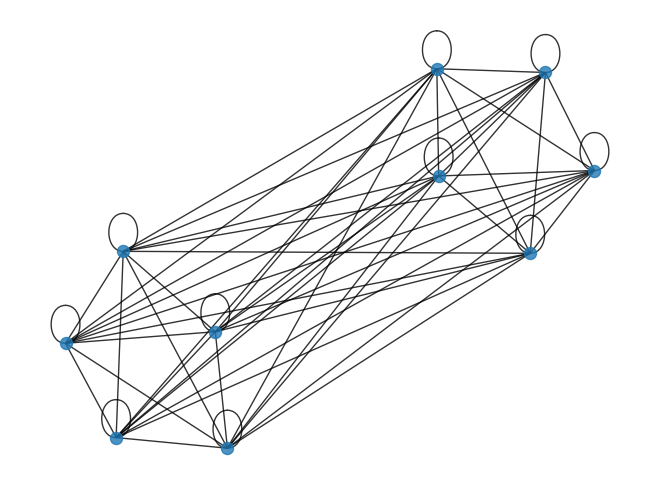

[0 1]


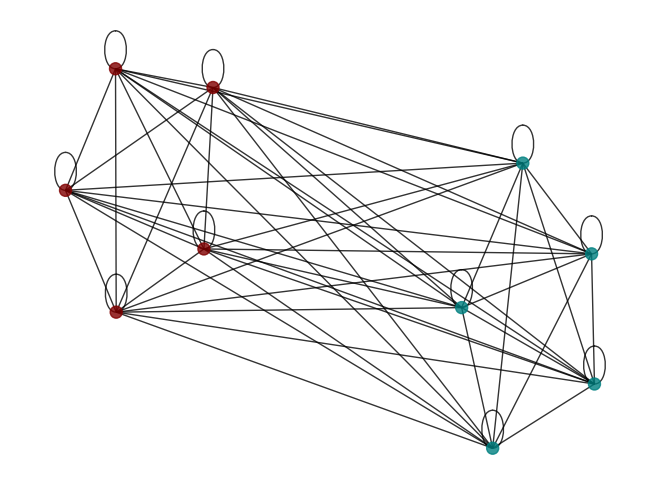

In [11]:
   
if __name__=='__main__':
    P = np.array([
    [0.20, 0.20, 0.20, 0.20, 0.15, 0.01, 0.01, 0.01, 0.01, 0.01],
    [0.20, 0.20, 0.20, 0.20, 0.15, 0.01, 0.01, 0.01, 0.01, 0.01],
    [0.20, 0.20, 0.20, 0.20, 0.15, 0.01, 0.01, 0.01, 0.01, 0.01],
    [0.20, 0.20, 0.20, 0.20, 0.15, 0.01, 0.01, 0.01, 0.01, 0.01],
    [0.15, 0.20, 0.20, 0.20, 0.20, 0.01, 0.01, 0.01, 0.01, 0.01],

    [0.01, 0.01, 0.01, 0.01, 0.01, 0.20, 0.20, 0.20, 0.20, 0.15],
    [0.01, 0.01, 0.01, 0.01, 0.01, 0.20, 0.20, 0.20, 0.20, 0.15],
    [0.01, 0.01, 0.01, 0.01, 0.01, 0.20, 0.20, 0.20, 0.20, 0.15],
    [0.01, 0.01, 0.01, 0.01, 0.01, 0.20, 0.20, 0.20, 0.20, 0.15],
    [0.01, 0.01, 0.01, 0.01, 0.01, 0.15, 0.20, 0.20, 0.20, 0.20]
    ])

    
    G = P2G(P)
    print(G)

    plt.figure(1)
    plt.ion()
    plt.clf()
    pos = nx.spring_layout(G)    # visualize graph
    nx.draw(G, pos, node_size = 75, alpha = 0.8)
    plt.show()


    comms,unique_comms = Louvain(G) 
    print(unique_comms)
    cmap = {
        0 : 'maroon',
        1 : 'teal',
        2 : 'black', 
        3 : 'orange',
        4 : 'green',
        5 : 'yellow',
        6 : 'cyan',
        7 : 'magenta',
        8 : 'red',
        9 : 'blue',
        10: 'green'
    }

    node_cmap = [cmap[v] for _,v in comms.items()]

    plt.figure(2)
    plt.clf()
    pos = nx.spring_layout(G)
    nx.draw(G, pos, node_size = 75, alpha = 0.8, node_color=node_cmap)
    plt.show()

    """
    GG = nx.Graph()  # or DiGraph, MultiGraph, MultiDiGraph, etc
    GG.add_weighted_edges_from([(0, 1, 3.0), (1, 2, 7.5)])



    G = nx.Graph([(1, 2), (2, 3), (3, 4)])
    weight = 0.1
    G.add_weighted_edges_from(list((5, n, weight) for n in G.nodes))
    """
